# Atividade I — Bank Marketing

**Julia Egute e Pedro Perroni**

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
print('Importações concluídas.')

Importações concluídas.


## 1. Análise Exploratória

### 1.1 Carregamento e visão geral da base

In [183]:
df = pd.read_csv('/bank_marketing_completo.csv')
print('dimensões:', df.shape)

dimensões: (41188, 21)


In [184]:
df.head()

,idade,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,...,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3m,numero_empregados,aderiu
0,56,empregado_domestico,casado,fundamental_4anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
1,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
2,37,servicos,casado,ensino_medio,nao,sim,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
3,40,administrativo,casado,fundamental_6anos,nao,nao,nao,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao
4,56,servicos,casado,ensino_medio,nao,nao,sim,telefone_fixo,mai,seg,...,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,nao


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade                        41188 non-null  int64  
 1   profissao                    41188 non-null  object 
 2   estado_civil                 41188 non-null  object 
 3   escolaridade                 41188 non-null  object 
 4   inadimplente                 41188 non-null  object 
 5   financiamento_imobiliario    41188 non-null  object 
 6   emprestimo_pessoal           41188 non-null  object 
 7   meio_contato                 41188 non-null  object 
 8   mes                          41188 non-null  object 
 9   dia_semana                   41188 non-null  object 
 10  duracao_ligacao_seg          41188 non-null  int64  
 11  contatos_campanha_atual      41188 non-null  int64  
 12  dias_desde_ultimo_contato    41188 non-null  int64  
 13  contatos_anterio

In [186]:
df.isna().sum()

,0
idade,0
profissao,0
estado_civil,0
escolaridade,0
inadimplente,0
financiamento_imobiliario,0
emprestimo_pessoal,0
meio_contato,0
mes,0
dia_semana,0


In [187]:
df.describe().T[['min', 'max', 'mean']]

,min,max,mean
idade,17.000,98.000,40.024060
duracao_ligacao_seg,0.000,4918.000,258.285010
contatos_campanha_atual,1.000,56.000,2.567593
dias_desde_ultimo_contato,0.000,999.000,962.475454
contatos_anteriores,0.000,7.000,0.172963
taxa_variacao_emprego,-3.400,1.400,0.081886
indice_precos_consumidor,92.201,94.767,93.575664
indice_confianca_consumidor,-50.800,-26.900,-40.502600
euribor_3m,0.634,5.045,3.621291
numero_empregados,4963.600,5228.100,5167.035911


In [188]:
df.describe(include='object')

,profissao,estado_civil,escolaridade,inadimplente,financiamento_imobiliario,emprestimo_pessoal,meio_contato,mes,dia_semana,resultado_campanha_anterior,aderiu
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,administrativo,casado,superior,nao,sim,nao,celular,mai,qui,inexistente,nao
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


### 1.2 Distribuição da variável-alvo

aderiu
nao    0.887346
sim    0.112654
Name: proportion, dtype: float64


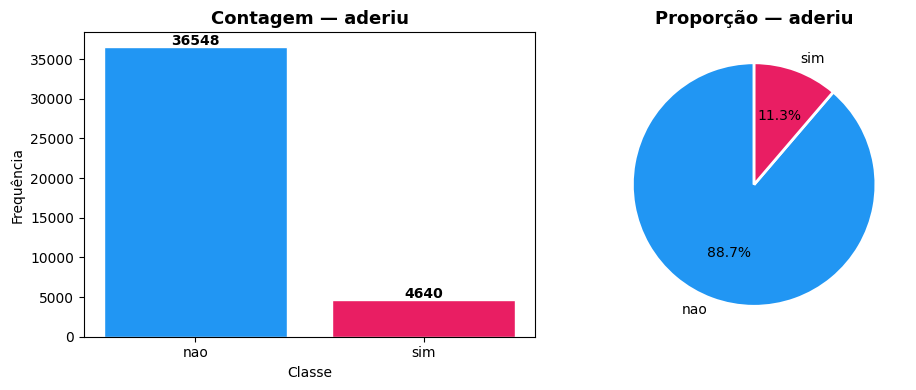

>>> A base é DESBALANCEADA: ~88,7% NÃO aderiram e ~11,3% aderiram.
>>> Isso afeta a escolha da métrica principal — acurácia pode ser enganosa.


In [189]:
# Proporção da variável-alvo
print(df['aderiu'].value_counts(normalize=True))

contagem = df['aderiu'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de barras
axes[0].bar(contagem.index, contagem.values,
            color=['#2196F3', '#E91E63'], edgecolor='white')
axes[0].set_title('Contagem — aderiu', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Frequência')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.1f%%',
            colors=['#2196F3', '#E91E63'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporção — aderiu', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('>>> A base é DESBALANCEADA: ~88,7% NÃO aderiram e ~11,3% aderiram.')
print('>>> Isso afeta a escolha da métrica principal — acurácia pode ser enganosa.')

### 1.3 Valores ausentes e inconsistências

In [190]:
# Valores desconhecidos nas categóricas
cols_cat = df.select_dtypes(include='object').columns
print('Ocorrências de "desconhecido" por coluna:')
for col in cols_cat:
    n = (df[col] == 'desconhecido').sum()
    if n > 0:
        print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')

# Valor especial 999 em dias_desde_ultimo_contato
n999 = (df['dias_desde_ultimo_contato'] == 999).sum()
print(f'\nValor 999 em dias_desde_ultimo_contato: {n999} ({n999/len(df)*100:.1f}%)')
print('>>> 999 indica que o cliente nunca foi contatado em campanha anterior.')

Ocorrências de "desconhecido" por coluna:
  profissao: 330 (0.8%)
  estado_civil: 80 (0.2%)
  escolaridade: 1731 (4.2%)
  inadimplente: 8597 (20.9%)
  financiamento_imobiliario: 990 (2.4%)
  emprestimo_pessoal: 990 (2.4%)

Valor 999 em dias_desde_ultimo_contato: 39673 (96.3%)
>>> 999 indica que o cliente nunca foi contatado em campanha anterior.


### 1.4 Visualização 1 — Taxa de adesão por profissão

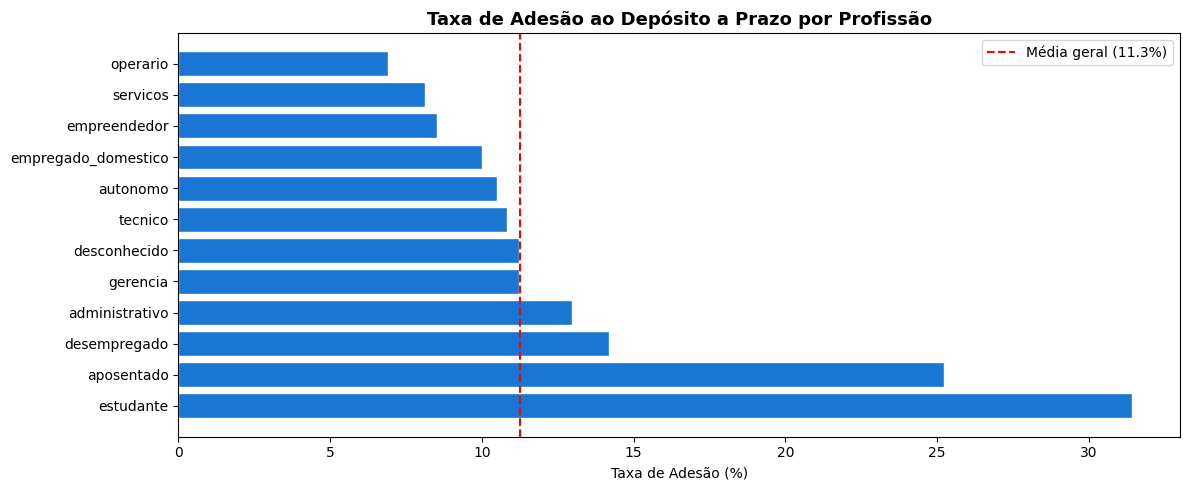

>>> Estudantes e aposentados apresentam as maiores taxas de adesão.


In [191]:
# Taxa de adesão por profissão
taxa_profissao = (
    df.groupby('profissao')['aderiu']
    .apply(lambda x: (x == 'sim').mean() * 100)
    .sort_values(ascending=False)
    .reset_index()
)
taxa_profissao.columns = ['profissao', 'taxa_adesao']

media_geral = (df['aderiu'] == 'sim').mean() * 100

plt.figure(figsize=(12, 5))
plt.barh(taxa_profissao['profissao'], taxa_profissao['taxa_adesao'],
         color='#1976D2', edgecolor='white')
plt.axvline(media_geral, color='red', linestyle='--', linewidth=1.5,
            label=f'Média geral ({media_geral:.1f}%)')
plt.xlabel('Taxa de Adesão (%)')
plt.title('Taxa de Adesão ao Depósito a Prazo por Profissão', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print('>>> Estudantes e aposentados apresentam as maiores taxas de adesão.')

### 1.5 Visualização 2 — Taxa de adesão por mês e contexto macroeconômico

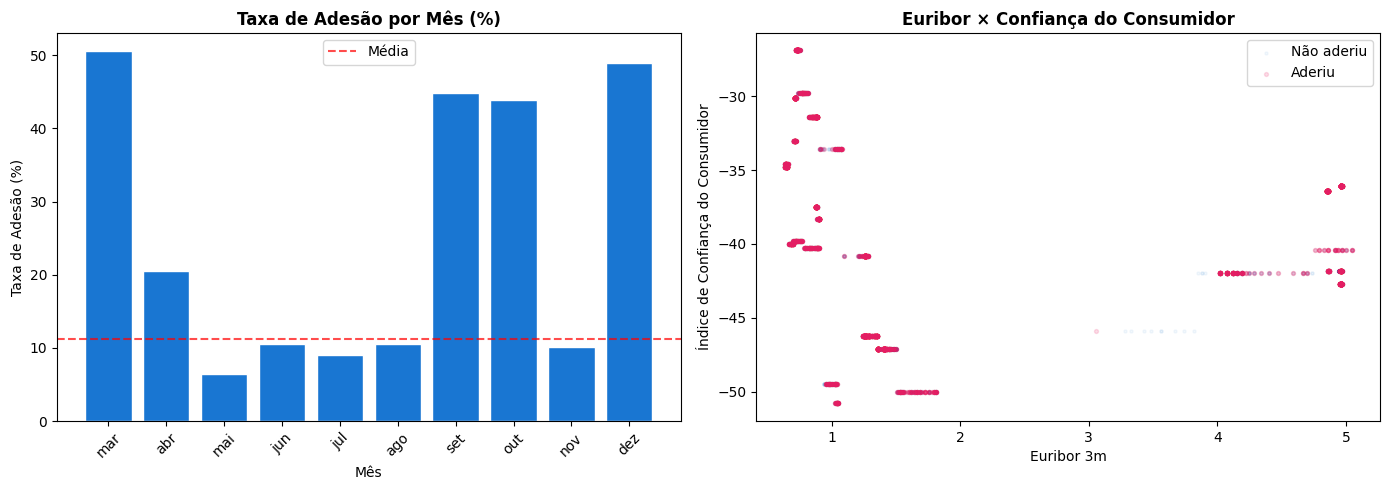

O gráfico descreve associações nesta amostra; não demonstra causalidade.
Os indicadores econômicos descrevem o período do contato, não apenas o cliente.


In [192]:
# Adesão por mês (ordem de calendário)
ordem_meses = ['jan', 'fev', 'mar', 'abr', 'mai', 'jun',
               'jul', 'ago', 'set', 'out', 'nov', 'dez']
meses_presentes = [m for m in ordem_meses if m in df['mes'].unique()]

taxa_mes = (
    df.groupby('mes')['aderiu']
    .apply(lambda x: (x == 'sim').mean() * 100)
    .reindex(meses_presentes)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(taxa_mes.index, taxa_mes.values, color='#1976D2', edgecolor='white')
axes[0].axhline(media_geral, color='red', linestyle='--', alpha=0.7, label='Média')
axes[0].set_title('Taxa de Adesão por Mês (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Taxa de Adesão (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Euribor vs confiança do consumidor por classe
axes[1].scatter(
    df[df['aderiu'] == 'nao']['euribor_3m'],
    df[df['aderiu'] == 'nao']['indice_confianca_consumidor'],
    alpha=0.05, c='#1976D2', s=5, label='Não aderiu'
)
axes[1].scatter(
    df[df['aderiu'] == 'sim']['euribor_3m'],
    df[df['aderiu'] == 'sim']['indice_confianca_consumidor'],
    alpha=0.15, c='#E91E63', s=8, label='Aderiu'
)
axes[1].set_xlabel('Euribor 3m')
axes[1].set_ylabel('Índice de Confiança do Consumidor')
axes[1].set_title('Euribor × Confiança do Consumidor', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print('O gráfico descreve associações nesta amostra; não demonstra causalidade.')
print('Os indicadores econômicos descrevem o período do contato, não apenas o cliente.')

### 1.6 Visualização 3 — Duração da ligação vs adesão

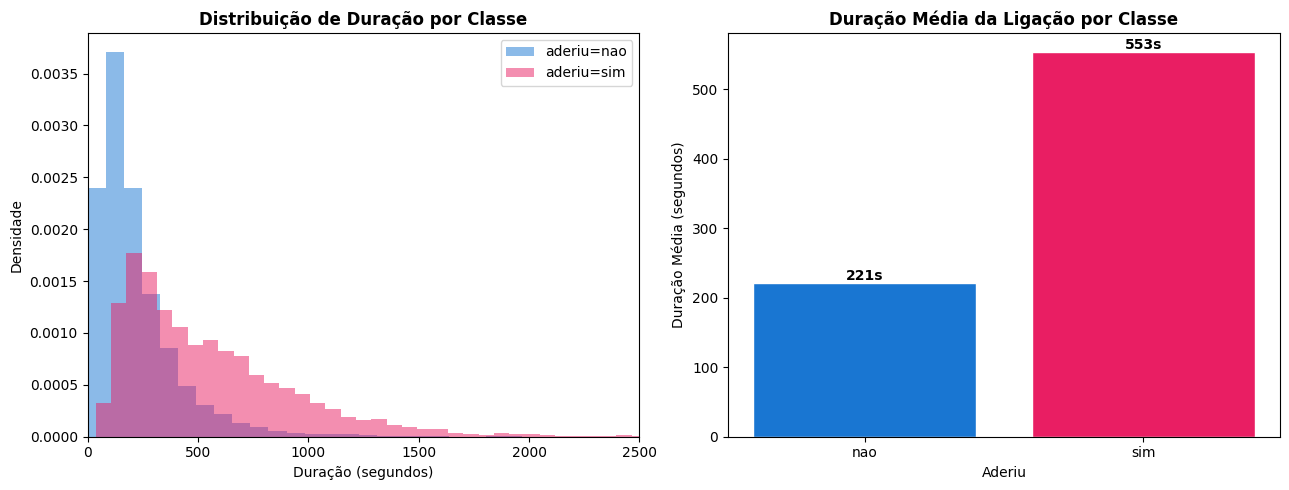

>>> IMPORTANTE: duracao_ligacao_seg é um forte preditor, MAS viola o cenário principal.
>>> A duração só é conhecida APÓS a ligação — inclui-la seria data leakage.
>>> Portanto, será EXCLUÍDA do Cenário Principal.


In [193]:
# Distribuição de duração da ligação por classe
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramas sobrepostos
for classe, cor in [('nao', '#1976D2'), ('sim', '#E91E63')]:
    axes[0].hist(
        df[df['aderiu'] == classe]['duracao_ligacao_seg'],
        bins=60, alpha=0.5, color=cor, label=f'aderiu={classe}', density=True
    )
axes[0].set_xlabel('Duração (segundos)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Duração por Classe', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 2500)

# Média por classe
media_dur = df.groupby('aderiu')['duracao_ligacao_seg'].mean()
axes[1].bar(media_dur.index, media_dur.values, color=['#1976D2', '#E91E63'], edgecolor='white')
axes[1].set_title('Duração Média da Ligação por Classe', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Aderiu')
axes[1].set_ylabel('Duração Média (segundos)')
for i, v in enumerate(media_dur.values):
    axes[1].text(i, v + 5, f'{v:.0f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('>>> IMPORTANTE: duracao_ligacao_seg é um forte preditor, MAS viola o cenário principal.')
print('>>> A duração só é conhecida APÓS a ligação — inclui-la seria data leakage.')
print('>>> Portanto, será EXCLUÍDA do Cenário Principal.')

### 1.7 Correlação entre variáveis numéricas

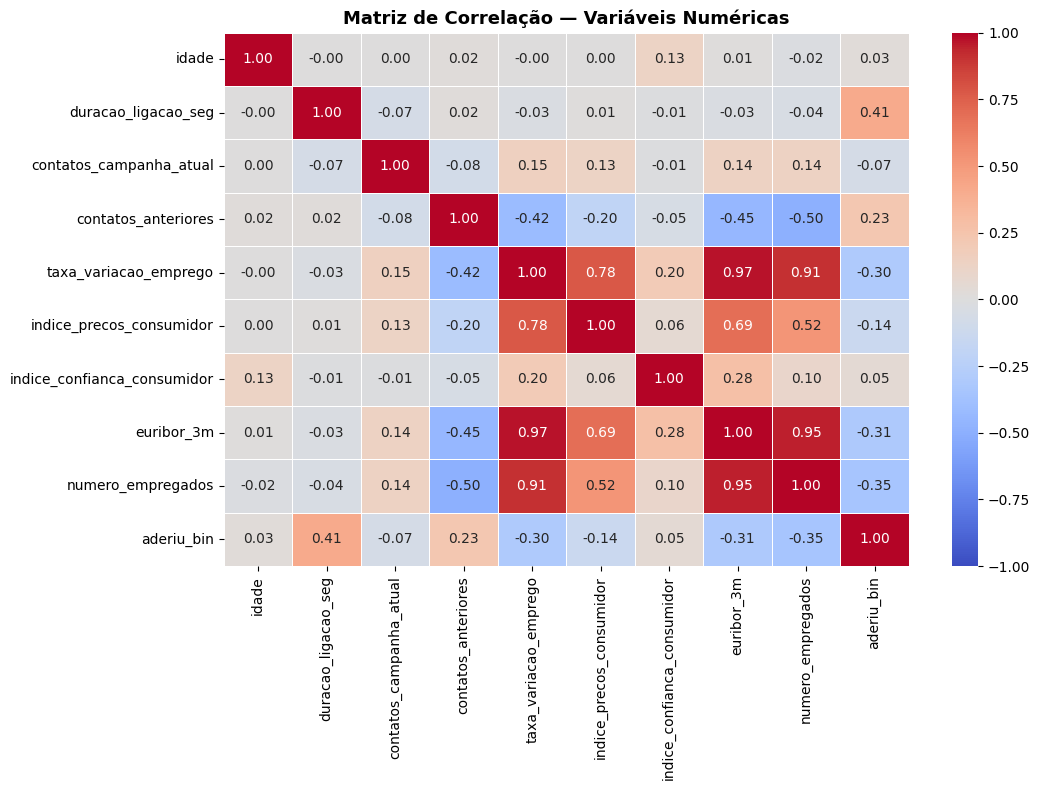

>>> Alta correlação entre indicadores macroeconômicos — comportamento esperado.
A coluna dias_desde_ultimo_contato foi excluída deste gráfico porque 999 não representa dias reais.


In [194]:
# Heatmap de correlação
numericas = df.select_dtypes(include=['int64', 'float64']).copy()
numericas = numericas.drop(columns='dias_desde_ultimo_contato')
numericas['aderiu_bin'] = (df['aderiu'] == 'sim').astype(int)

plt.figure(figsize=(11, 8))
sns.heatmap(
    numericas.corr().round(2), annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Matriz de Correlação — Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('>>> Alta correlação entre indicadores macroeconômicos — comportamento esperado.')
print('A coluna dias_desde_ultimo_contato foi excluída deste gráfico porque 999 não representa dias reais.')

### 1.8 Registros repetidos e limites da análise
Foram encontradas 12 linhas idênticas. Consideramos essas repetições redundantes e as removemos, ficando com 41.176 registros. Como não há um identificador do contato, não é possível confirmar se eram duplicações ou contatos diferentes com os mesmos dados. Os valores desconhecido e o código 999 serão tratados na preparação.

In [195]:
print('Linhas exatamente repetidas:', df.duplicated().sum())
print(df.groupby('profissao')['aderiu'].agg(['count']))
df = df.drop_duplicates().copy()
print('Dimensões após remoção:', df.shape)
print(df['aderiu'].value_counts())

Linhas exatamente repetidas: 12
                     count
profissao                 
administrativo       10422
aposentado            1720
autonomo              1421
desconhecido           330
desempregado          1014
empreendedor          1456
empregado_domestico   1060
estudante              875
gerencia              2924
operario              9254
servicos              3969
tecnico               6743
Dimensões após remoção: (41176, 21)
aderiu
nao    36537
sim     4639
Name: count, dtype: int64


## 2. Preparação dos dados:

### 2.1 Alvo, valor especial e categorias desconhecidas
`aderiu` é o alvo e não entra nos atributos. Mantemos `desconhecido` como categoria própria: falta de informação não significa `nao`.

Em `dias_desde_ultimo_contato`, 999 significa que não houve contato anterior. Criamos `nunca_contatado` e substituímos 999 por `NaN`. Essas duas operações são regras fixas do significado da coluna, sem estimar estatísticas. A mediana será aprendida dentro do Pipeline, somente no treino de cada partição. O valor imputado não significa um contato real; a flag preserva essa distinção.

In [196]:
X = df.drop(columns='aderiu').copy()
y = df['aderiu'].map({'nao': 0, 'sim': 1})

X['nunca_contatado'] = (X['dias_desde_ultimo_contato'] == 999).astype(int)
X['dias_desde_ultimo_contato'] = X['dias_desde_ultimo_contato'].replace(999, np.nan)

print(y.value_counts(normalize=True))

aderiu
0    0.887337
1    0.112663
Name: proportion, dtype: float64


### 2.2 Unica divisão estratificada: 70% treino e 30% teste
A mesma divisão de linhas será usada nos dois cenários e nos três modelos. A estratificação preserva aproximadamente a proporção das classes. Usamos `random_state=42` nas operações aleatórias. Nenhuma mediana, escala ou categoria do codificador é aprendida antes desta divisão.

In [197]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
print('Treino:', X_treino.shape)
print('Teste:', X_teste.shape)
print('Proporção de sim no treino:', y_treino.mean())
print('Proporção de sim no teste:', y_teste.mean())

Treino: (28823, 21)
Teste: (12353, 21)
Proporção de sim no treino: 0.1126530895465427
Proporção de sim no teste: 0.11268517768963004


### 2.3 Cenários de avaliação
No cenário principal, retiramos duracao_ligacao_seg, pois a duração só é conhecida depois da ligação. Também retiramos contatos_campanha_atual, por incluir o contato registrado e não termos uma contagem confirmada para o momento anterior à decisão.
Mantivemos mês, dia da semana e meio de contato considerando que a data e o canal da ligação já foram planejados. Também consideramos que o histórico do cliente e os indicadores econômicos estavam disponíveis naquele momento.
No cenário completo, mantivemos todos os atributos, com a mesma preparação. Esse cenário permite comparar os resultados, mas não pode ser usado para decidir quem contatar antes da ligação, pois inclui sua duração. A variável aderiu é o alvo e não entra nos atributos de nenhum cenário.

In [198]:
EXCLUIDOS_PRINCIPAL = ['duracao_ligacao_seg', 'contatos_campanha_atual']

X_pr_treino = X_treino.drop(columns=EXCLUIDOS_PRINCIPAL)
X_pr_teste = X_teste.drop(columns=EXCLUIDOS_PRINCIPAL)
X_co_treino = X_treino.copy()
X_co_teste = X_teste.copy()

print('Principal:', X_pr_treino.shape[1], 'atributos antes da codificação')
print('Completo:', X_co_treino.shape[1], 'atributos antes da codificação')

Principal: 19 atributos antes da codificação
Completo: 21 atributos antes da codificação


### 2.4 Preparação com Pipeline
Nas colunas numéricas, usamos a mediana para preencher valores ausentes e o StandardScaler para padronizar as escalas. Nas categóricas, usamos o OneHotEncoder para transformar as categorias em colunas numéricas.
Os três modelos recebem a mesma preparação. O Pipeline aprende as transformações somente no treino de cada partição e aplica os valores aprendidos aos dados de validação ou teste, evitando vazamento de informações.

In [199]:
def montar_preparacao(X_dados):
    num = X_dados.select_dtypes(include=[np.number]).columns.tolist()
    cat = X_dados.select_dtypes(exclude=[np.number]).columns.tolist()

    pipe_num = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escala', StandardScaler())
    ])
    pipe_cat = Pipeline([
        ('onehot', OneHotEncoder(
            drop='first', handle_unknown='ignore', sparse_output=False
        ))
    ])

    preparacao = ColumnTransformer([
        ('num', pipe_num, num),
        ('cat', pipe_cat, cat)
    ])
    return preparacao

def montar_modelo(X_dados, estimador):
    return Pipeline([
        ('preparacao', montar_preparacao(X_dados)),
        ('modelo', estimador)
    ])

## 3. Modelagem e escolha usando somente o treino

### 3.1 Métrica principal: F1 macro
A acurácia isolada é insuficiente porque a maioria dos contatos não resulta em adesão. O F1 macro é a média do F1 das duas classes, dando o mesmo peso a `nao` e `sim`. Assim, avalia o equilíbrio entre precisão e recall por classe sem deixar a classe majoritária dominar a média. Ele não atribui explicitamente maior custo a um falso negativo.

Usamos F1 macro nas buscas, na validação e na comparação principal. Também analisamos precisão e recall de `sim`, que mostram, respectivamente, o aproveitamento dos contatos priorizados e a parcela dos aderentes identificada. Não afirmamos que F1 macro seja a única escolha válida ou uma medida de lucro.

In [200]:
METRICA = 'f1_macro'
print('Acurácia de prever sempre nao no treino:', (y_treino == 0).mean())
print('Métrica principal:', METRICA)

Acurácia de prever sempre nao no treino: 0.8873469104534573
Métrica principal: f1_macro


### 3.2 Conjunto usado nas buscas
As buscas de k e C usam o treino completo, sem acessar o teste. Cada cenário usa exatamente as mesmas linhas. A preparação é reaprendida em cada partição da validação.

Após escolher os parâmetros, cada modelo é ajustado no treino completo. `cv=5` em classificadores usa partições estratificadas, como explicado no material 09; não há embaralhamento aleatório nessa configuração.

In [201]:
treinos = {'Principal': X_pr_treino, 'Completo': X_co_treino}
modelos = {}
parametros = []
buscas = {}

### 3.3 k-NN: escolha de k por GridSearchCV
Testamos os valores de k usados no material de validação cruzada. Mantemos distância euclidiana e pesos uniformes. A padronização evita que atributos de grande escala dominem as distâncias. Fazemos uma busca independente em cada cenário, sempre usando somente o treino.

In [172]:
for cenario, X_dados in treinos.items():
    pipe_knn = montar_modelo(X_dados, KNeighborsClassifier())
    grade_knn = {'modelo__n_neighbors': [1, 3, 5, 9, 15, 21, 31, 51]}

    busca = GridSearchCV(pipe_knn, grade_knn, cv=5, scoring=METRICA, n_jobs=1)
    busca.fit(X_dados, y_treino)
    melhor_k = busca.best_params_['modelo__n_neighbors']

    modelo = montar_modelo(X_dados, KNeighborsClassifier(n_neighbors=melhor_k))
    modelo.fit(X_dados, y_treino)
    modelos[(cenario, 'k-NN')] = modelo
    buscas[(cenario, 'k-NN')] = busca
    parametros.append({'Cenário': cenario, 'Modelo': 'k-NN',
                       'Parâmetro': 'k', 'Valor': melhor_k})
    print(cenario, 'melhor k:', melhor_k, 'F1 macro na busca:', busca.best_score_)

Principal melhor k: 5 F1 macro na busca: 0.6556611692498767
Completo melhor k: 9 F1 macro na busca: 0.7200730704003092


### 3.4 Naive Bayes: GaussianNB
Escolhemos o GaussianNB porque a base contém atributos numéricos contínuos, como taxas e índices econômicos, cujos valores queremos preservar.
Após a codificação, também existem colunas binárias, que não seguem uma distribuição normal. Além disso, alguns atributos são correlacionados, o que limita a hipótese de independência do modelo. Por isso, reconhecemos essas limitações e avaliamos seu desempenho pela validação cruzada. Mantivemos os parâmetros padrão e a mesma preparação dos demais modelos.

In [173]:
for cenario, X_dados in treinos.items():
    modelo = montar_modelo(X_dados, GaussianNB())
    modelo.fit(X_dados, y_treino)
    modelos[(cenario, 'GaussianNB')] = modelo
    print('GaussianNB treinado:', cenario)

GaussianNB treinado: Principal
GaussianNB treinado: Completo


### 3.5 Regressão logística: escolha de C por GridSearchCV
Testamos C por validação cruzada no treino de cada cenário. C menor representa regularização mais forte. Usamos `max_iter=1000`, como no notebook da aula, e semente 42. Os avisos não são ocultados: se houver falta de convergência, ela precisa ser verificada.

In [174]:
for cenario, X_dados in treinos.items():
    pipe_lr = montar_modelo(X_dados, LogisticRegression(max_iter=1000, random_state=SEED))
    grade_lr = {'modelo__C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

    busca = GridSearchCV(pipe_lr, grade_lr, cv=5, scoring=METRICA, n_jobs=1)
    busca.fit(X_dados, y_treino)
    melhor_C = busca.best_params_['modelo__C']

    modelo = montar_modelo(X_dados, LogisticRegression(
        C=melhor_C, max_iter=1000, random_state=SEED
    ))
    modelo.fit(X_dados, y_treino)
    modelos[(cenario, 'Regressão Logística')] = modelo
    buscas[(cenario, 'Regressão Logística')] = busca
    parametros.append({'Cenário': cenario, 'Modelo': 'Regressão Logística',
                       'Parâmetro': 'C', 'Valor': melhor_C})
    print(cenario, 'melhor C:', melhor_C, 'F1 macro na busca:', busca.best_score_)

print(pd.DataFrame(parametros).to_string(index=False))

Principal melhor C: 10.0 F1 macro na busca: 0.6464518917555082
Completo melhor C: 5.0 F1 macro na busca: 0.7377727034012571
  Cenário              Modelo Parâmetro  Valor
Principal                k-NN         k    5.0
 Completo                k-NN         k    9.0
Principal Regressão Logística         C   10.0
 Completo Regressão Logística         C    5.0


### 3.6 Validação cruzada estratificada no treino completo
Executamos cinco partições no treino completo para cada modelo do cenário principal, refazendo toda a preparação em cada partição. Reportamos média e desvio-padrão do F1 macro. A média é usada para escolher o candidato antes de avaliar o teste.

Como os hiperparâmetros foram escolhidos usando esse mesmo treino, estes valores de validação podem ter algum otimismo de seleção. O conjunto de teste reservado fornece a avaliação final independente dos ajustes. Diferenças pequenas entre médias não demonstram superioridade estatística.

In [175]:
cv_resultados = []
for nome in ['k-NN', 'GaussianNB', 'Regressão Logística']:
    modelo = modelos[('Principal', nome)]
    notas = cross_val_score(modelo, X_pr_treino, y_treino, cv=5, scoring=METRICA)
    cv_resultados.append({'Modelo': nome, 'F1 macro CV média': notas.mean(),
                          'F1 macro CV DP': notas.std()})
    print(nome, 'scores:', notas)
    print('Média:', notas.mean(), 'Desvio-padrão:', notas.std())

tabela_cv = pd.DataFrame(cv_resultados)
nome_escolhido = tabela_cv.loc[tabela_cv['F1 macro CV média'].idxmax(), 'Modelo']
print('Candidato escolhido pelo F1 macro médio no treino:', nome_escolhido)

k-NN scores: [0.64268378 0.66251954 0.65383177 0.66395545 0.6553153 ]
Média: 0.6556611692498767 Desvio-padrão: 0.007585662553213384
GaussianNB scores: [0.65491493 0.65674706 0.65124694 0.66850191 0.66085707]
Média: 0.658453582864398 Desvio-padrão: 0.00590111330902324
Regressão Logística scores: [0.64866614 0.64985538 0.65202246 0.65708738 0.62462811]
Média: 0.6464518917555082 Desvio-padrão: 0.011286354771214313
Candidato escolhido pelo F1 macro médio no treino: GaussianNB


## 4. Avaliação final no conjunto de teste
Os parâmetros e o candidato já foram definidos usando o treino. A seguir, avaliamos os três modelos nos dois cenários, conforme o enunciado, sem alterar parâmetros ou limiares a partir destes resultados. Cada matriz usa linhas para a classe real e colunas para a prevista; a ordem é `nao`, `sim`.


 Principal — k-NN
              precision    recall  f1-score   support

         nao       0.91      0.97      0.94     10961
         sim       0.54      0.28      0.37      1392

    accuracy                           0.89     12353
   macro avg       0.73      0.62      0.65     12353
weighted avg       0.87      0.89      0.88     12353



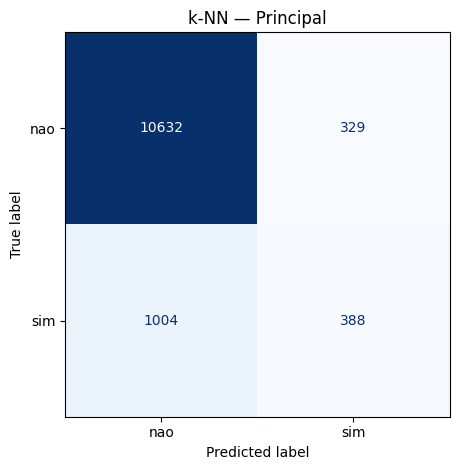


 Principal — GaussianNB
              precision    recall  f1-score   support

         nao       0.93      0.88      0.91     10961
         sim       0.36      0.51      0.42      1392

    accuracy                           0.84     12353
   macro avg       0.65      0.70      0.67     12353
weighted avg       0.87      0.84      0.85     12353



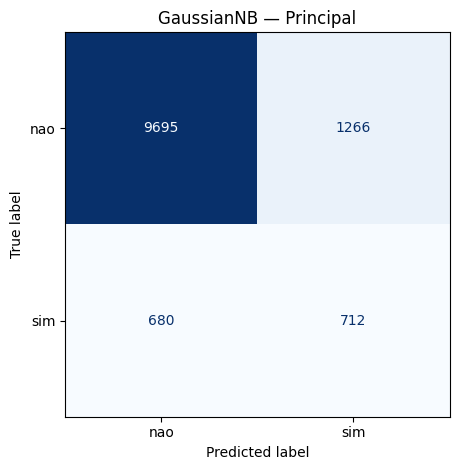


 Principal — Regressão Logística
              precision    recall  f1-score   support

         nao       0.91      0.99      0.95     10961
         sim       0.66      0.21      0.32      1392

    accuracy                           0.90     12353
   macro avg       0.78      0.60      0.63     12353
weighted avg       0.88      0.90      0.88     12353



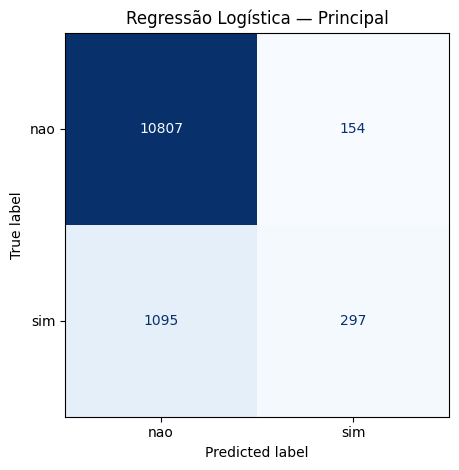


 Completo — k-NN
              precision    recall  f1-score   support

         nao       0.93      0.97      0.95     10961
         sim       0.60      0.40      0.48      1392

    accuracy                           0.90     12353
   macro avg       0.76      0.68      0.71     12353
weighted avg       0.89      0.90      0.89     12353



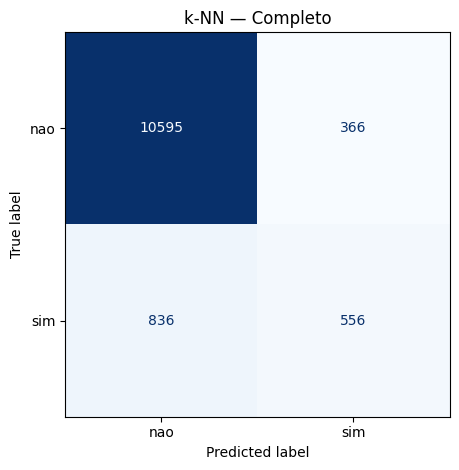


 Completo — GaussianNB
              precision    recall  f1-score   support

         nao       0.94      0.88      0.91     10961
         sim       0.39      0.58      0.47      1392

    accuracy                           0.85     12353
   macro avg       0.67      0.73      0.69     12353
weighted avg       0.88      0.85      0.86     12353



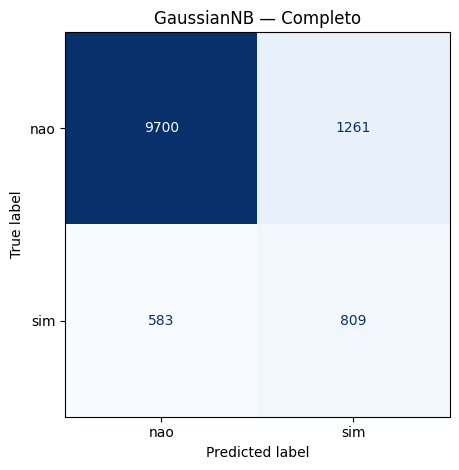


 Completo — Regressão Logística
              precision    recall  f1-score   support

         nao       0.93      0.97      0.95     10961
         sim       0.65      0.42      0.51      1392

    accuracy                           0.91     12353
   macro avg       0.79      0.69      0.73     12353
weighted avg       0.90      0.91      0.90     12353



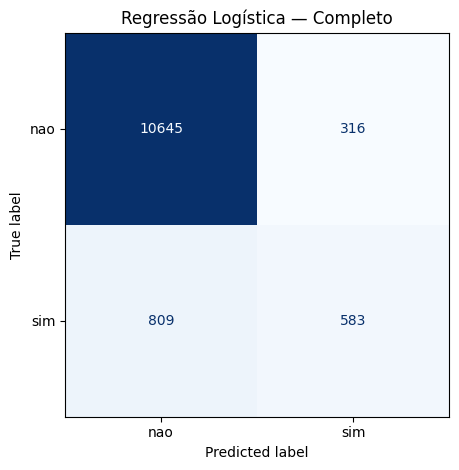

In [176]:
def avaliar_modelo(nome, cenario, modelo, X_avaliacao):
    y_prev = modelo.predict(X_avaliacao)
    print('\n', cenario, '—', nome)
    print(classification_report(y_teste, y_prev, labels=[0, 1],
                                target_names=['nao', 'sim'], zero_division=0))
    cm = confusion_matrix(y_teste, y_prev, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['nao', 'sim']).plot(
        cmap='Blues', colorbar=False
    )
    plt.title(nome + ' — ' + cenario)
    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    resultado = {'Cenário': cenario, 'Modelo': nome,
                 'Acurácia': accuracy_score(y_teste, y_prev),
                 'F1 macro': f1_score(y_teste, y_prev, average='macro', zero_division=0),
                 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp}
    for classe, rotulo in [(0, 'nao'), (1, 'sim')]:
        resultado['Precisão ' + rotulo] = precision_score(y_teste, y_prev, pos_label=classe, zero_division=0)
        resultado['Recall ' + rotulo] = recall_score(y_teste, y_prev, pos_label=classe, zero_division=0)
        resultado['F1 ' + rotulo] = f1_score(y_teste, y_prev, pos_label=classe, zero_division=0)
    return resultado

resultados = []
for cenario, X_avaliacao in [('Principal', X_pr_teste), ('Completo', X_co_teste)]:
    for nome in ['k-NN', 'GaussianNB', 'Regressão Logística']:
        resultados.append(avaliar_modelo(nome, cenario, modelos[(cenario, nome)], X_avaliacao))

### 4.1 Tabela única de resultados
As métricas por classe, o F1 macro e as contagens de erros são do teste. As duas colunas identificadas por **CV** são do treino completo e aparecem somente no cenário principal. `NaN` nessas colunas do cenário completo significa que essa validação final não foi solicitada para ele; as buscas de k e C nos dois cenários usaram validação cruzada.

In [177]:
tabela = pd.DataFrame(resultados)
tabela['F1 macro CV média'] = np.nan
tabela['F1 macro CV DP'] = np.nan
for resultado_cv in cv_resultados:
    linha = (tabela['Cenário'] == 'Principal') & (tabela['Modelo'] == resultado_cv['Modelo'])
    tabela.loc[linha, 'F1 macro CV média'] = resultado_cv['F1 macro CV média']
    tabela.loc[linha, 'F1 macro CV DP'] = resultado_cv['F1 macro CV DP']

ordem = ['Cenário', 'Modelo', 'Acurácia', 'Precisão nao', 'Recall nao', 'F1 nao',
         'Precisão sim', 'Recall sim', 'F1 sim', 'F1 macro',
         'F1 macro CV média', 'F1 macro CV DP', 'TN', 'FP', 'FN', 'TP']
tabela = tabela[ordem]
tabela.round(4)

,Cenário,Modelo,Acurácia,Precisão nao,Recall nao,F1 nao,Precisão sim,Recall sim,F1 sim,F1 macro,F1 macro CV média,F1 macro CV DP,TN,FP,FN,TP
0,Principal,k-NN,0.8921,0.9137,0.9700,0.9410,0.5411,0.2787,0.3679,0.6545,0.6557,0.0076,10632,329,1004,388
1,Principal,GaussianNB,0.8425,0.9345,0.8845,0.9088,0.3600,0.5115,0.4226,0.6657,0.6585,0.0059,9695,1266,680,712
2,Principal,Regressão Logística,0.8989,0.9080,0.9860,0.9454,0.6585,0.2134,0.3223,0.6338,0.6465,0.0113,10807,154,1095,297
3,Completo,k-NN,0.9027,0.9269,0.9666,0.9463,0.6030,0.3994,0.4806,0.7134,NaN,NaN,10595,366,836,556
4,Completo,GaussianNB,0.8507,0.9433,0.8850,0.9132,0.3908,0.5812,0.4674,0.6903,NaN,NaN,9700,1261,583,809
5,Completo,Regressão Logística,0.9089,0.9294,0.9712,0.9498,0.6485,0.4188,0.5089,0.7294,NaN,NaN,10645,316,809,583


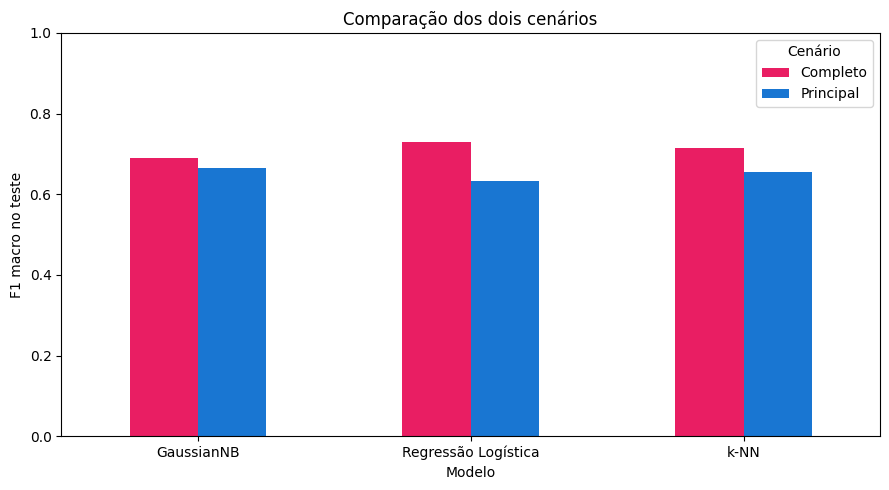

Cenário              Completo  Principal
Modelo                                  
GaussianNB             0.6903     0.6657
Regressão Logística    0.7294     0.6338
k-NN                   0.7134     0.6545
Variação de F1 macro (Completo - Principal):
Modelo
GaussianNB             0.0246
Regressão Logística    0.0955
k-NN                   0.0590
dtype: float64


In [178]:
comparacao = tabela.pivot(index='Modelo', columns='Cenário', values='F1 macro')
comparacao.plot(kind='bar', figsize=(9, 5), color=['#E91E63', '#1976D2'])
plt.ylabel('F1 macro no teste')
plt.xlabel('Modelo')
plt.title('Comparação dos dois cenários')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
print(comparacao.round(4))
print('Variação de F1 macro (Completo - Principal):')
print((comparacao['Completo'] - comparacao['Principal']).round(4))

### 4.2 Análise dos erros e custo para o banco
- **Falso positivo (FP):** prever adesão para um contato que não aderiu. Se a previsão orientar a campanha, há risco de ligação improdutiva, custo operacional e uso da capacidade do operador.
- **Falso negativo (FN):** prever não adesão para um contato que aderiu. Se o banco deixar de priorizá-lo, pode perder uma oportunidade de captação.

Consideramos que perder um possível aderente pode ser mais custoso que fazer uma ligação adicional. Porém, a base não informa esses custos, e muitos falsos positivos também podem sobrecarregar a equipe. Por isso, analisamos os dois tipos de erro sem calcular um impacto financeiro.

In [179]:
principais = tabela[tabela['Cenário'] == 'Principal']
print(principais[['Modelo', 'FP', 'FN', 'Precisão sim', 'Recall sim', 'F1 macro']].round(4).to_string(index=False))
for _, linha in principais.iterrows():
    print(linha['Modelo'] + ':')
    print(f"  Identificou {linha['Recall sim']:.1%} dos aderentes reais no teste.")
    print(f"  Entre os previstos como sim, {linha['Precisão sim']:.1%} realmente aderiram.")

             Modelo   FP   FN  Precisão sim  Recall sim  F1 macro
               k-NN  329 1004        0.5411      0.2787    0.6545
         GaussianNB 1266  680        0.3600      0.5115    0.6657
Regressão Logística  154 1095        0.6585      0.2134    0.6338
k-NN:
  Identificou 27.9% dos aderentes reais no teste.
  Entre os previstos como sim, 54.1% realmente aderiram.
GaussianNB:
  Identificou 51.1% dos aderentes reais no teste.
  Entre os previstos como sim, 36.0% realmente aderiram.
Regressão Logística:
  Identificou 21.3% dos aderentes reais no teste.
  Entre os previstos como sim, 65.9% realmente aderiram.


### 4.3 Cinco coeficientes de maior magnitude — regressão logística
Selecionamos os cinco coeficientes de maior valor absoluto, mantendo seus sinais. Um coeficiente positivo indica associação com maior probabilidade prevista de adesão; um negativo indica o contrário, considerando os demais atributos constantes.
Nas variáveis numéricas padronizadas, o efeito corresponde ao aumento de um desvio-padrão. Nas categóricas, a comparação é feita com a categoria de referência. Os coeficientes representam mudanças no logaritmo das chances, e não aumentos ou reduções diretos em pontos percentuais. Essas associações não demonstram causalidade.


Cinco maiores coeficientes em magnitude — Principal
num__taxa_variacao_emprego                 -2.3182
cat__mes_mar                                1.3941
num__indice_precos_consumidor               1.1175
cat__meio_contato_telefone_fixo            -0.7983
cat__resultado_campanha_anterior_sucesso    0.7942
dtype: float64


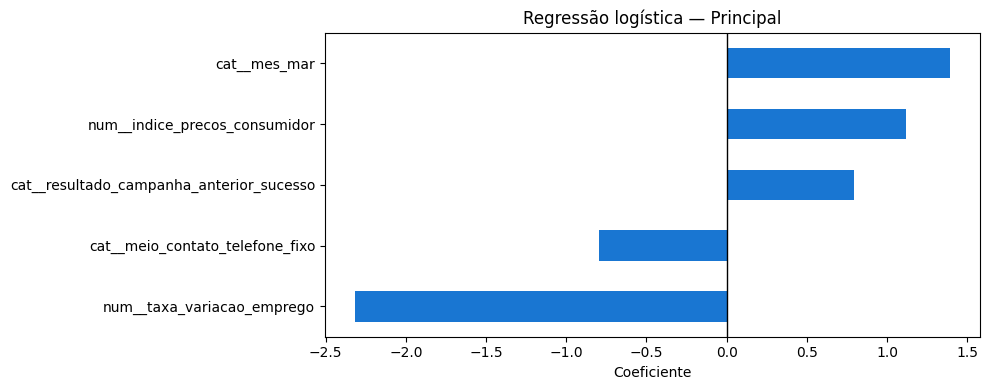

num__taxa_variacao_emprego: um aumento de um desvio-padrão associa-se a menor probabilidade prevista de adesão, mantendo os demais atributos constantes.
cat__mes_mar: essa categoria associa-se a maior probabilidade prevista de adesão em relação à referência, mantendo os demais atributos constantes.
num__indice_precos_consumidor: um aumento de um desvio-padrão associa-se a maior probabilidade prevista de adesão, mantendo os demais atributos constantes.
cat__meio_contato_telefone_fixo: essa categoria associa-se a menor probabilidade prevista de adesão em relação à referência, mantendo os demais atributos constantes.
cat__resultado_campanha_anterior_sucesso: essa categoria associa-se a maior probabilidade prevista de adesão em relação à referência, mantendo os demais atributos constantes.
Categorias de referência:
profissao : administrativo
estado_civil : casado
escolaridade : analfabeto
inadimplente : desconhecido
financiamento_imobiliario : desconhecido
emprestimo_pessoal : desconhecido

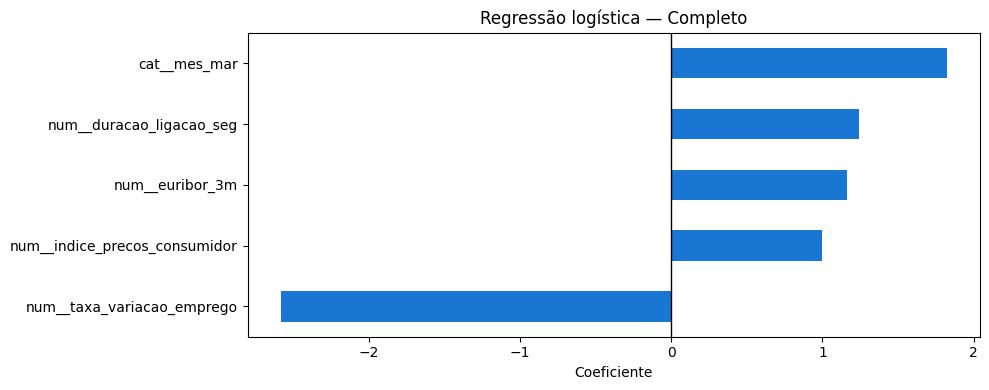

num__taxa_variacao_emprego: um aumento de um desvio-padrão associa-se a menor probabilidade prevista de adesão, mantendo os demais atributos constantes.
cat__mes_mar: essa categoria associa-se a maior probabilidade prevista de adesão em relação à referência, mantendo os demais atributos constantes.
num__duracao_ligacao_seg: um aumento de um desvio-padrão associa-se a maior probabilidade prevista de adesão, mantendo os demais atributos constantes.
num__euribor_3m: um aumento de um desvio-padrão associa-se a maior probabilidade prevista de adesão, mantendo os demais atributos constantes.
num__indice_precos_consumidor: um aumento de um desvio-padrão associa-se a maior probabilidade prevista de adesão, mantendo os demais atributos constantes.
Categorias de referência:
profissao : administrativo
estado_civil : casado
escolaridade : analfabeto
inadimplente : desconhecido
financiamento_imobiliario : desconhecido
emprestimo_pessoal : desconhecido
meio_contato : celular
mes : abr
dia_semana : q

In [180]:
coeficientes_cenarios = {}
for cenario in ['Principal', 'Completo']:
    pipe_lr = modelos[(cenario, 'Regressão Logística')]
    nomes = pipe_lr.named_steps['preparacao'].get_feature_names_out()
    coeficientes = pd.Series(pipe_lr.named_steps['modelo'].coef_[0], index=nomes)
    top5 = coeficientes.sort_values(key=abs, ascending=False).head(5)
    coeficientes_cenarios[cenario] = top5
    print('\nCinco maiores coeficientes em magnitude —', cenario)
    print(top5.round(4))

    top5.sort_values().plot(kind='barh', figsize=(10, 4), color='#1976D2')
    plt.axvline(0, color='black', linewidth=1)
    plt.xlabel('Coeficiente')
    plt.title('Regressão logística — ' + cenario)
    plt.tight_layout()
    plt.show()

    for atributo, valor in top5.items():
        direcao = 'maior' if valor > 0 else 'menor'
        if atributo.startswith('num__'):
            print(f'{atributo}: um aumento de um desvio-padrão associa-se a {direcao} probabilidade prevista de adesão, mantendo os demais atributos constantes.')
        else:
            print(f'{atributo}: essa categoria associa-se a {direcao} probabilidade prevista de adesão em relação à referência, mantendo os demais atributos constantes.')

    cat_treinadas = pipe_lr.named_steps['preparacao'].transformers_[1][2]
    encoder = pipe_lr.named_steps['preparacao'].named_transformers_['cat'].named_steps['onehot']
    print('Categorias de referência:')
    for coluna, categorias in zip(cat_treinadas, encoder.categories_):
        print(coluna, ':', categorias[0])

### Leitura dos cinco maiores coeficientes no cenário principal

Todos os efeitos abaixo são associações condicionais, mantendo os demais atributos constantes.

| Atributo | Coeficiente | Interpretação |
|---|---:|---|
| Taxa de variação do emprego | −2,3182 | Aumento de um desvio-padrão está associado a menor probabilidade prevista de adesão. |
| Mês: março | +1,3941 | Março está associado a maior probabilidade prevista que abril, categoria de referência; isso não demonstra um efeito causal do mês. |
| Índice de preços do consumidor | +1,1175 | Aumento de um desvio-padrão está associado a maior probabilidade prevista, condicionado aos outros indicadores. |
| Meio de contato: telefone fixo | −0,7983 | Contato por telefone fixo está associado a menor probabilidade prevista que por celular, categoria de referência. |
| Resultado anterior: sucesso | +0,7942 | Sucesso anterior está associado a maior probabilidade prevista que fracasso anterior, categoria de referência. |

Esses números são coeficientes no logaritmo das chances, não variações percentuais diretas na probabilidade. As correlações entre indicadores econômicos limitam interpretações isoladas de suas magnitudes.

## 5. Discussão e conclusão
O candidato abaixo foi escolhido pelo F1 macro médio na validação do treino, antes de consultar as métricas do teste. A comparação final também considera a capacidade de identificar aderentes, a precisão dos contatos priorizados e as limitações do experimento.

In [181]:
escolhido = principais[principais['Modelo'] == nome_escolhido].iloc[0]
print('Candidato escolhido na validação do treino:', nome_escolhido)
print(f"F1 macro CV: {escolhido['F1 macro CV média']:.4f} ± {escolhido['F1 macro CV DP']:.4f}")
print(f"F1 macro no teste: {escolhido['F1 macro']:.4f}")
print(f"Precisão da classe sim: {escolhido['Precisão sim']:.1%}")
print(f"Recall da classe sim: {escolhido['Recall sim']:.1%}")
print('O modelo é um candidato para o objetivo definido, sem comprovação de maior lucro ou de superioridade estatística.')

Candidato escolhido na validação do treino: GaussianNB
F1 macro CV: 0.6585 ± 0.0059
F1 macro no teste: 0.6657
Precisão da classe sim: 36.0%
Recall da classe sim: 51.1%
O modelo é um candidato para o objetivo definido, sem comprovação de maior lucro ou de superioridade estatística.


### Interpretação dos resultados desta execução
O GaussianNB apresentou o maior F1 macro médio na validação do cenário principal: 0,6585 ± 0,0059. O k-NN ficou próximo, com 0,6557 ± 0,0076, enquanto a regressão logística obteve 0,6465 ± 0,0113. Pelo critério escolhido, selecionamos o GaussianNB, mas a pequena diferença em relação ao k-NN não permite afirmar uma superioridade definitiva.
No teste, o GaussianNB identificou 51,1% dos aderentes, mas teve precisão de 36,0% para essa classe. Isso significa que encontrou mais clientes que aderiram, porém também gerou mais falsos positivos. A regressão logística apresentou precisão maior, de 65,9%, mas identificou apenas 21,3% dos aderentes.
No cenário completo, o F1 macro aumentou de 0,6545 para 0,7134 no k-NN, de 0,6657 para 0,6903 no GaussianNB e de 0,6338 para 0,7294 na regressão logística. Mesmo assim, esse cenário não é adequado para decidir quem contatar, pois inclui a duração da ligação, conhecida somente depois do contato. Como retiramos duas colunas e ajustamos os parâmetros separadamente, não podemos atribuir toda a diferença apenas à duração.
Os resultados se limitam às campanhas e ao período analisado. A divisão aleatória mistura registros de diferentes momentos e não mostra diretamente o desempenho em campanhas futuras. Como melhorias, seria interessante avaliar o modelo em um período posterior e obter os custos reais das ligações improdutivas e das oportunidades perdidas.




## 6. Uso de IA :
Foi utilizado ChatGPT para revisar o código, corrigir a preparação e a avaliação a interpretação dos resultados.

